[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/land-economics-ilr-uni-bonn/sat-agri-econ/blob/main/earth_engine/2026/02_research_bridge_notebooks/01_getting_data_out_of_earth_engine.ipynb)

# Research Bridge 1 — Getting Data Out Of Earth Engine

**Scales up:** `02b_EE_client_vs_server`, `11_spatial_reducer`, `12_spatial_reducer_regions`,
`15_landsat_time_series_extraction`.

> **What was changed for sharing.** Set `cloud_project` to your own Earth Engine Cloud project id; confidential inputs are replaced with public data; and batch exports (`task.start()`) are commented out so you do not launch long Drive jobs by accident. Re-enable an export only after you have checked its region, scale, CRS, and bands.

## What this notebook teaches

In the lessons you kept computation server-side and only pulled *small* results to Python with
`.getInfo()`. Real analysis eventually needs the results on your own machine. This notebook shows how
to bring Earth Engine results **directly into local Python** — pandas/GeoPandas tables and xarray
rasters — **without exporting to Google Drive first**:

- **Tables (FeatureCollections)** -> pandas / GeoPandas, three ways: `geemap.ee_to_df` / `ee_to_gdf`,
  and the official `ee.data.computeFeatures` with a `PANDAS_DATAFRAME` / `GEOPANDAS_GEODATAFRAME`
  output. No Drive/GCS round-trip needed for modest tables.
- **Rasters / data cubes** -> `xarray` via **xee** (Part 2 below): open an ImageCollection directly
  as a labelled `(time, y, x)` cube and process it locally.

**Mental model:** server-side Earth Engine builds a lazy
computation graph; bringing data local is a deliberate *materialization* step. Pull *small summaries*
for diagnostics, and *export* (or stream with xee over a small region) for anything large — never try
to `.getInfo()` a continental table.

**Sanity-check as you read:** how many rows/timesteps come back? Do the values look physically
plausible (e.g. max temperature in a sensible range)? Is the geometry/CRS what you expected?

In [1]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install xee rioxarray

In [2]:
import ee
# import geemap.core as geemap  # in colab
import geemap
import eerepr
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
import ee

cloud_project = 'ee-hadicu06'  # replace with your cloud project id
try:
    ee.Initialize(project=cloud_project)
except:
    ee.Authenticate()
    ee.Initialize(project=cloud_project)

# FeatureCollection to Pandas DataFrame and GeoPandas GeoDataFrame

In [4]:
country = ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level1") \
    .filter(ee.Filter.eq('ADM0_NAME', 'Indonesia'))
java_filter = ee.Filter.stringContains('ADM1_NAME', 'Jawa')
sel_provs = country.filter(java_filter)

terra_climate = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE') \
    .filterBounds(sel_provs)

tmax = terra_climate.select('tmmx')

def calculate_yearly_mean_tmax_by_region(year):
    year = ee.Number(year)
    start_date = ee.Date.fromYMD(year, 1, 1)
    end_date = start_date.advance(1, 'year')

    filtered = tmax.filterDate(start_date, end_date)
    reduced = filtered.reduce(ee.Reducer.mean())

    def compute_mean(feature):
        region_mean = reduced.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=feature.geometry(),
            scale=5000,
            maxPixels=1e10
        )
        return ee.Feature(
            feature.geometry(),
            region_mean.set('regionName', feature.get('ADM1_NAME'))
                       .set('year', year.format('%d'))
        )

    return sel_provs.map(compute_mean)

years = ee.List.sequence(2000, 2023)
results = years.map(calculate_yearly_mean_tmax_by_region)
results_fc = ee.FeatureCollection(results).flatten()


In [5]:
%%time
results_fc.limit(3)

CPU times: user 159 µs, sys: 21 µs, total: 180 µs
Wall time: 186 µs


## Using geemap package

In [6]:
%%time
results_df_geemap = geemap.ee_to_df(results_fc)

CPU times: user 11.1 ms, sys: 138 µs, total: 11.3 ms
Wall time: 5.76 s


In [7]:
display(type(results_df_geemap))
results_df_geemap.head()

pandas.core.frame.DataFrame

,regionName,tmmx_mean,year
0,Jawa Barat,289.492101,2000
1,Jawa Tengah,300.697021,2000
2,Jawa Timur,298.590468,2000
3,Jawa Barat,286.980593,2001
4,Jawa Tengah,298.803187,2001


In [8]:
results_df_geemap.to_csv('results_df_geemap.csv', index=False)

In [9]:
%%time
results_gdf_geemap = geemap.ee_to_gdf(results_fc)

CPU times: user 840 ms, sys: 72.2 ms, total: 912 ms
Wall time: 12.6 s


In [10]:
display(type(results_gdf_geemap))
results_gdf_geemap.head()

geopandas.geodataframe.GeoDataFrame

,geometry,regionName,tmmx_mean,year
0,GEOMETRYCOLLECTION (LINESTRING (106.85081 -6.3...,Jawa Barat,289.492101,2000
1,GEOMETRYCOLLECTION (LINESTRING (108.55983 -7.3...,Jawa Tengah,300.697021,2000
2,GEOMETRYCOLLECTION (LINESTRING (111.06834 -8.0...,Jawa Timur,298.590468,2000
3,GEOMETRYCOLLECTION (LINESTRING (106.85081 -6.3...,Jawa Barat,286.980593,2001
4,GEOMETRYCOLLECTION (LINESTRING (108.55983 -7.3...,Jawa Tengah,298.803187,2001


In [11]:
results_gdf_geemap.to_file("results_gdf_geemap.gpkg", driver="GPKG")

## Using EE Python API (ee.data.computeFeatures)

In [12]:
%%time
results_df_computeFeatures = ee.data.computeFeatures({
    'expression': results_fc,
    'fileFormat': 'PANDAS_DATAFRAME'
})

CPU times: user 426 ms, sys: 52.4 ms, total: 479 ms
Wall time: 5.51 s


In [13]:
display(type(results_df_computeFeatures))
results_df_computeFeatures.head()

pandas.core.frame.DataFrame

,geo,regionName,tmmx_mean,year
0,"{'type': 'GeometryCollection', 'geometries': [...",Jawa Barat,289.492101,2000
1,"{'type': 'GeometryCollection', 'geometries': [...",Jawa Tengah,300.697021,2000
2,"{'type': 'GeometryCollection', 'geometries': [...",Jawa Timur,298.590468,2000
3,"{'type': 'GeometryCollection', 'geometries': [...",Jawa Barat,286.980593,2001
4,"{'type': 'GeometryCollection', 'geometries': [...",Jawa Tengah,298.803187,2001


In [14]:
results_df_computeFeatures = results_df_computeFeatures.drop(columns=['geo'])

In [15]:
results_df_computeFeatures.to_csv('results_df_computeFeatures.csv', index=False)

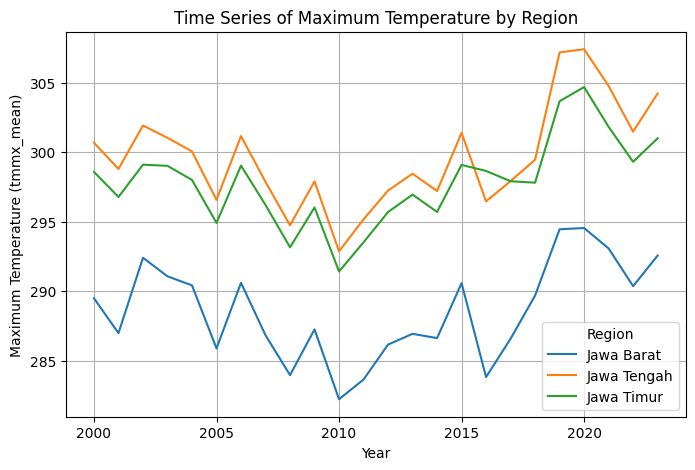

In [16]:
results_df_computeFeatures['year'] = results_df_computeFeatures['year'].astype(int)

regions = results_df_computeFeatures['regionName'].unique()

fig, ax = plt.subplots(figsize=(8, 5))  # Create figure and axis

for region in regions:
    region_data = results_df_computeFeatures[results_df_computeFeatures['regionName'] == region]
    ax.plot(region_data['year'], region_data['tmmx_mean'], label=region)

ax.set_xlabel('Year')
ax.set_ylabel('Maximum Temperature (tmmx_mean)')
ax.set_title('Time Series of Maximum Temperature by Region')
ax.legend(title='Region')
ax.grid(True)

plt.show()

In [17]:
%%time
results_gdf_computeFeatures = ee.data.computeFeatures({
    'expression': results_fc,
    'fileFormat': 'GEOPANDAS_GEODATAFRAME'
})

CPU times: user 797 ms, sys: 91.4 ms, total: 888 ms
Wall time: 11.1 s


In [18]:
display(type(results_gdf_computeFeatures))
results_gdf_computeFeatures.head()

geopandas.geodataframe.GeoDataFrame

,geometry,regionName,tmmx_mean,year
0,GEOMETRYCOLLECTION (LINESTRING (106.85081 -6.3...,Jawa Barat,289.492101,2000
1,GEOMETRYCOLLECTION (LINESTRING (108.55983 -7.3...,Jawa Tengah,300.697021,2000
2,GEOMETRYCOLLECTION (LINESTRING (111.06834 -8.0...,Jawa Timur,298.590468,2000
3,GEOMETRYCOLLECTION (LINESTRING (106.85081 -6.3...,Jawa Barat,286.980593,2001
4,GEOMETRYCOLLECTION (LINESTRING (108.55983 -7.3...,Jawa Tengah,298.803187,2001


In [19]:
results_gdf_computeFeatures.crs = 'EPSG:4326'

In [20]:
results_gdf_computeFeatures.to_file("results_gdf_computeFeatures.gpkg", driver="GPKG")

## Part 2 — Rasters And Data Cubes: Pulling Images Locally With `xee`

The methods above bring **tables** into local Python. For **rasters / data cubes** the modern bridge
is **xee**, which lets `xarray` open an Earth Engine `ImageCollection` directly as a labelled
`(time, y, x)` cube — without exporting to Drive/GCS first. This is the practical face of the
 discussion of *lazy evaluation*, *Dask*, *rioxarray*, and *bringing the
algorithm to the data*.

Keep the **region small** while learning — with xee every requested pixel is streamed to your machine,
so this is the opposite trade-off from a server-side `reduceRegions`. Use xee when you genuinely need
array-style local processing (custom time-series smoothing, gap-filling, models that are awkward in
Earth Engine); prefer server-side reducers when you only need summaries.

In [ ]:
import xarray as xr
from xee import helpers
from shapely.geometry import box as shapely_box

# The high-volume endpoint is recommended when xee requests many tiles.
ee.Initialize(
    project='ee-hadicu06',
    opt_url='https://earthengine-highvolume.googleapis.com',
)

tmax_ic = (
    ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE')
    .select('tmmx')
    .filterDate('2018-01-01', '2021-01-01')
)

# Define the output grid (the Earth Engine "pull" model: you choose the grid, xee resamples on the
# fly). xee.helpers.fit_geometry takes a *shapely* geometry and returns the {crs, crs_transform,
# shape_2d} parameters that xr.open_dataset(engine='ee') expects. Keep the area small -- every pixel
# is streamed to your machine. (Pattern from the spatialthoughts xee tutorial.)
aoi = shapely_box(110.0, -7.9, 110.5, -7.5)   # a small area on Java, Indonesia (lon/lat)
output_crs = 'EPSG:3857'   # Web Mercator (metres)
output_scale = 1000        # 1 km
grid_params = helpers.fit_geometry(
    geometry=aoi,
    geometry_crs='EPSG:4326',                       # CRS of `aoi`
    grid_crs=output_crs,
    grid_scale=(output_scale, -output_scale),       # (x, y); negative y is north-up
)
print('grid params:', grid_params)

# Open the collection as an xarray Dataset on that grid.
ds = xr.open_dataset(tmax_ic, engine='ee', **grid_params)
ds    # inspect dims (time + two spatial dims) and data variables

grid params: {'crs': 'EPSG:3857', 'crs_transform': (1000.0, 0.0, 12245000.0, 0.0, -1000.0, -837000.0), 'shape_2d': (56, 46)}


<xarray.Dataset> Size: 372kB
Dimensions:  (time: 36, y: 46, x: 56)
Coordinates:
  * time     (time) datetime64[ns] 288B 2018-01-01 2018-02-01 ... 2020-12-01
  * y        (y) float64 368B -8.375e+05 -8.385e+05 ... -8.815e+05 -8.825e+05
  * x        (x) float64 448B 1.225e+07 1.225e+07 ... 1.23e+07 1.23e+07
Data variables:
    tmmx     (time, y, x) float32 371kB ...
Attributes: (12/18)
    date_range:               [-378691200000, 1606780800000]
    description:              <p>TerraClimate is a dataset of monthly climate...
    keywords:                 ['climate', 'drought', 'evapotranspiration', 'g...
    period:                   0
    product_tags:             ['climate', 'global', 'monthly', 'geophysical',...
    provider:                 University of California Merced
    ...                       ...
    type_name:                ImageCollection
    visualization_0_bands:    tmmx
    visualization_0_max:      300.0
    visualization_0_min:      -300.0
    visualization_0_name:     Maximum Temperature
    visualization_0_palette:  1a3678,2955bc,5699ff,8dbae9,acd1ff,caebff,e5f9f...

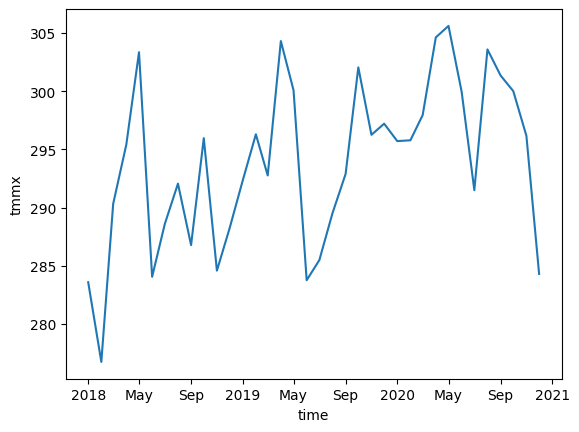

In [22]:
# A region-mean time series, materialized locally with .compute().
# (We average over whatever the two spatial dims are named -- xee may call them lon/lat or X/Y.)
spatial_dims = [d for d in ds['tmmx'].dims if d != 'time']
region_ts = ds['tmmx'].mean(dim=spatial_dims).compute()

# Sanity check: a plausible seasonal cycle of max temperature, one value per month.
region_ts.plot()

In [ ]:
# Save the time series as a CSV for econometrics. xarray's .to_dataframe() converts the
# labelled array into a pandas DataFrame (one row per timestep); pandas .to_csv() writes it.
ts_df = region_ts.to_dataframe(name='tmmx').reset_index()
print(ts_df.head())


        time        tmmx
0 2018-01-01  283.584625
1 2018-02-01  276.735626
2 2018-03-01  290.326080
3 2018-04-01  295.411499
4 2018-05-01  303.359070


In [ ]:
ts_df.to_csv('tmmx_region_timeseries.csv', index=False)  


In [ ]:
# Local processing then save -- e.g. one timestep as a Cloud-Optimized GeoTIFF.
# Enable rioxarray's accessor and write a CRS before saving. 
import rioxarray  
da = ds['tmmx'].isel(time=0).rio.write_crs('EPSG:4326')
da.rio.to_raster('tmmx_2018-01.tif', driver='COG')

# For out-of-memory cubes, ds.chunk('auto') turns the arrays into lazy Dask arrays so the work is
# streamed and parallelized instead of loaded all at once.

## Closing Reflection

You now have two complementary exits from Earth Engine: **tables** to pandas/GeoPandas for econometric
merging, and **rasters** to xarray for local array processing. Both are *materialization* steps —
decide consciously which side of the server/local boundary each operation belongs on, and keep the
local footprint small. The next bridges show the table side at research scale.